The purpose of this notebook is to correct phenotype plots for Tsuboyama datasets using thermodynamic model.

### Datasets preprocessing 1

Obtaining dG from data from the paper and errors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def add_dg(df, name, table):
    """
    Filters and processes a DataFrame based on mutation data and thermodynamic parameters.

    Args:
        df (pd.DataFrame): The input DataFrame containing mutation data.
        name (str): The name of the dataset to filter from the table.
        table (pd.DataFrame): The table containing thermodynamic parameters for mutations.

    Returns:
        pd.DataFrame: A DataFrame with additional columns for the number of mutations, 
                      deltaG values, associated errors, and pair_name for double mutants.
    """
    # Create a copy of the input DataFrame to avoid modifying the original
    df = df.copy()

    # Add a column to count the number of mutations in each row
    df["num_mutations"] = df["mutant"].apply(lambda x: len(x.split(":")))

    # Initialize new columns for deltaG and error values
    df["dG"] = None
    df["error_t"] = None
    df["error_c"] = None
    df["pair_name"] = None  # New column to store pair_name for double mutants

    # Filter the table for rows matching the given name
    table_filtered = table[table["name"].str.contains(name, case=False, na=False)].copy()

    # Dictionaries to store deltaG values for single and double mutations
    single_mut_map = {}
    double_mut_map = {}

    # Populate the dictionaries with data from the filtered table
    for _, row in table_filtered.iterrows():
        mut_type = row.get("mut_type")
        deltaG = row.get("deltaG")
        error_t = row.get("fitting_error_t")
        error_c = row.get("fitting_error_c")
        pair_name = row.get("pair_name")  # Get pair_name if available

        # Handle double mutations
        if isinstance(mut_type, str) and len(mut_type.split(":")) == 2:
            muts = mut_type.split(":")
            if len(muts) == 2:
                key = tuple(sorted(muts))  # Sort to ensure consistent key ordering
                double_mut_map[key] = (deltaG, error_t, error_c, pair_name)

        # Handle single mutations
        elif isinstance(mut_type, str) and len(mut_type.split(":")) == 1:
            single_mut_map[mut_type] = (deltaG, error_t, error_c)

    # Define a lookup function to assign deltaG and error values to rows in the DataFrame
    def lookup(row):
        if row["num_mutations"] == 2:
            # For double mutations, look up the deltaG value using the sorted key
            muts = row["mutant"].split(":")
            key = tuple(sorted(muts))
            val = double_mut_map.get(key)
            if val:
                # Assign deltaG, error values, and pair_name to the corresponding columns
                df.at[row.name, "error_t"] = val[1]
                df.at[row.name, "error_c"] = val[2]
                df.at[row.name, "pair_name"] = val[3]
                return val[0]
        elif row["num_mutations"] == 1:
            # For single mutations, look up deltaG and error values
            mut = row["mutant"]
            val = single_mut_map.get(mut)
            if val:
                # Assign error values to the corresponding columns
                df.at[row.name, "error_t"] = val[1]
                df.at[row.name, "error_c"] = val[2]
                return val[0]
        return None

    # Apply the lookup function to calculate deltaG for each row
    df["dG"] = df.apply(lookup, axis=1)

    return df

In [ ]:
import os

# Selected datasets: containing 2 mutations or more
# Read the selected datasets from the text file
with open("selected_datasets.txt", "r") as file:
    selected_datasets = [line.strip() for line in file.readlines()]
# dG values
table = pd.read_csv("Tsuboyama/Tsuboyama2023_Dataset2_Dataset3_20230416.csv")
# Iterate over all CSV files in the Tsuboyama folder
tsuboyama_folder = "Tsuboyama"
for file in os.listdir(tsuboyama_folder):
    if file.endswith(".csv") and file != "Tsuboyama2023_Dataset2_Dataset3_20230416.csv":
        # Read each CSV file into a DataFrame
        file_path = os.path.join(tsuboyama_folder, file)
        dataframe = pd.read_csv(file_path)
        name = file.split(".")[0].split("_")[-1]
        # Process the DataFrame to add deltaG values
        df = add_dg(dataframe, name, table)
        # Save the processed DataFrame to a new CSV file
        if file.split(".")[0] in selected_datasets:
            df.to_csv(f"Tsuboyama/to_plot_sum_dg/{file}")


/tmp/ipykernel_54533/3300290753.py:8: DtypeWarning: Columns (30,31,36) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv("Tsuboyama/Tsuboyama2023_Dataset2_Dataset3_20230416.csv")


In [8]:
tsuboyama_folder = "Tsuboyama/to_plot"
cnt = 0
for file in os.listdir(tsuboyama_folder):
    cnt += 1
print(f"Number of datasets: {cnt}")

Number of datasets: 50


### Dataset preprocessing 2

Adding reconstructed dG using thermodynamic model for double mutations

In [9]:
# import libaries

import csv
import numpy as np
import pandas as pd
import glob
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import pandas as pd
from operator import itemgetter
import seaborn as sns
from tqdm import tqdm
import math
import pickle
from scipy import stats

import numpyro
from jax import random, vmap

import os
#os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
#os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='0.5'

from numpyro.diagnostics import hpdi
import numpyro.distributions as dist
from numpyro import handlers
from numpyro.infer import MCMC, NUTS
from numpyro.infer import initialization
import jax.numpy, jax.scipy
import scipy.stats
from numpyro.infer.reparam import TransformReparam
import Bio
from scipy.special import softmax

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

gpu
Sat Apr 19 12:20:10 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-PCIE-16GB            On | 00000000:C1:00.0 Off |                    0 |
| N/A   30C    P0               35W / 250W|   4110MiB / 16384MiB |      2%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+---------------------

In [10]:
def additive_model(df_dg,aa_len):
    # aa_len: number of amino acids (usually 20)
    # df_dg: datafame including aa1, aa2 (index), and raw deltaG values 
    
    # first/second_aa_effect: coefficients representing first/second amino acid effects [aa_len]
    first_aa_effect = numpyro.sample("first_aa_effect", dist.Normal(np.resize(0.1, (aa_len)), 3))
    second_aa_effect = numpyro.sample("second_aa_effect", dist.Normal(np.resize(0.1, (aa_len)), 3))

    # list of index of 1st aa, index of 2nd aa, [length of df_dg]
    first_aa_index = list(df_dg['aa1'])
    second_aa_index = list(df_dg['aa2'])
    
    # list of observed deltaG [length of df_dg]
    obs_dg_list = jax.numpy.array(df_dg['dG'])
    
    # pred_aa_dg_list: predicted deltaG using aa_len x2 (usually 40 = 20x2) coefficients, then clip the data bewteen -1 to 5
    pred_aa_dg_list = jax.numpy.array([first_aa_effect[index] for index in first_aa_index])+jax.numpy.array([second_aa_effect[index] for index in second_aa_index])
    clipped_pred_aa_dg_list =  jax.numpy.clip(pred_aa_dg_list,-1,5)
    
    # sigma: uncertainty of the data
    sigma = numpyro.sample("sigma", dist.Exponential(1))   
    
    # fitting coefficients by assuming predicted deltaG matches observed dG
    numpyro.sample("obs_dg",dist.TransformedDistribution(dist.Normal(0, 1), dist.transforms.AffineTransform(clipped_pred_aa_dg_list,sigma)), obs = obs_dg_list)

In [11]:
aas='QENHDRKTSAGMCLVIWYFP'

In [12]:
def get_recon_dg(df_dmut):
    df_dmut = df_dmut[df_dmut['num_mutations'] == 2].copy()
    dmut_list = list(set(df_dmut['pair_name']))

    df_sum = pd.DataFrame()

    for dmut_name in dmut_list:

        sub_df = df_dmut[df_dmut['pair_name']==dmut_name]
        sub_df['aa1'] = [aas.index(x.split(':')[0][-1]) for x in sub_df['mutant']]
        sub_df['aa2'] = [aas.index(x.split(':')[1][-1]) for x in sub_df['mutant']]

        rng_key = random.PRNGKey(1)
        rng_key, rng_key_ = random.split(rng_key)

        kernel = NUTS(additive_model, init_strategy=initialization.init_to_feasible())
        mcmc = MCMC(kernel, num_warmup=100, num_samples=50, num_chains=1)


        mcmc.run(rng_key_,df_dg = sub_df,aa_len=20)
        samples_dg = mcmc.get_samples()

        first_aa_effect = np.median(samples_dg['first_aa_effect'],axis=0)
        second_aa_effect = np.median(samples_dg['second_aa_effect'],axis=0)

        sub_df['recon_dg'] = [first_aa_effect[aa1] + second_aa_effect[aa2] for aa1,aa2 in zip(sub_df['aa1'],sub_df['aa2'])]
        sub_df['thermodynamic_coupling'] = sub_df['dG'] - sub_df['recon_dg']
        df_sum = df_sum.append(sub_df)
    return df_sum

In [14]:
def get_recon_dg(df_dmut):
    """
    Reconstructs expected ΔG for double mutants using an additive thermodynamic model.
    Returns a DataFrame with reconstructed ΔG and thermodynamic coupling.

    Args:
        df_dmut (pd.DataFrame): Input DataFrame with columns 'mutant', 'dG', and 'pair_name'

    Returns:
        pd.DataFrame: Extended DataFrame with 'recon_dg' and 'thermodynamic_coupling'
    """
    # Keep only double mutants
    df_dmut = df_dmut[df_dmut['num_mutations'] == 2].copy()
    dmut_list = list(set(df_dmut['pair_name']))

    df_chunks = []

    for dmut_name in dmut_list:
        sub_df = df_dmut[df_dmut['pair_name'] == dmut_name].copy()

        # Safely assign aa1 and aa2 using .loc to avoid SettingWithCopyWarning
        sub_df.loc[:, 'aa1'] = [aas.index(x.split(':')[0][-1]) for x in sub_df['mutant']]
        sub_df.loc[:, 'aa2'] = [aas.index(x.split(':')[1][-1]) for x in sub_df['mutant']]

        rng_key = random.PRNGKey(1)
        rng_key, rng_key_ = random.split(rng_key)

        kernel = NUTS(additive_model, init_strategy=initialization.init_to_feasible())
        mcmc = MCMC(kernel, num_warmup=100, num_samples=50, num_chains=1)

        mcmc.run(rng_key_, df_dg=sub_df, aa_len=20)
        samples_dg = mcmc.get_samples()

        first_aa_effect = np.median(samples_dg['first_aa_effect'], axis=0)
        second_aa_effect = np.median(samples_dg['second_aa_effect'], axis=0)

        # Compute reconstructed ΔG and thermodynamic coupling using .loc
        sub_df.loc[:, 'recon_dg'] = [
            first_aa_effect[aa1] + second_aa_effect[aa2]
            for aa1, aa2 in zip(sub_df['aa1'], sub_df['aa2'])
        ]
        sub_df.loc[:, 'thermodynamic_coupling'] = sub_df['dG'] - sub_df['recon_dg']

        df_chunks.append(sub_df)

    # Combine all processed subsets into one DataFrame
    df_sum = pd.concat(df_chunks, ignore_index=True)
    return df_sum

In [16]:
import os

tsuboyama_folder = "Tsuboyama/to_plot_sum_dg"
for file in os.listdir(tsuboyama_folder):
    # Read each CSV file into a DataFrame
    file_path = os.path.join(tsuboyama_folder, file)
    dataframe = pd.read_csv(file_path)
    # Process the DataFrame to add reconstructed deltaG values
    df = get_recon_dg(dataframe)
    # Save the processed DataFrame to a new CSV file
    df.to_csv(f"Tsuboyama/to_plot_recon_dg/{file}")

sample: 100%|██████████| 150/150 [00:34<00:00,  4.37it/s, 7 steps of size 7.72e-02. acc. prob=0.84] 


### Error validation

Epistasis using reconstructed dGs is valid if abs(thermodynamic coupling) aka abs(dg - recon dG) is more than the sum of individual errors (ind error = max(error_t, error_c)) 

Epistasis using sum of individual mutations is valid if abs(dg - sum dG) is more than the sum of individual errors (ind error = max(error_t, error_c)) 

In [5]:
import os

tsuboyama_folder = "Tsuboyama/to_plot_sum_dg"
for file in os.listdir(tsuboyama_folder):
    file_path = os.path.join(tsuboyama_folder, file)
    singles = pd.read_csv(file_path)
    singles = singles[singles['num_mutations'] == 1]
    
    file_path = os.path.join("Tsuboyama/to_plot_recon_dg", file)
    doubles = pd.read_csv(file_path)

    doubles["valid"] = None
    for i, row in doubles.iterrows():
        mut1 = row["mutant"].split(":")[0]
        mut2 = row["mutant"].split(":")[1]
        
        if len(singles[singles["mutant"] == mut1]) == 0 or len(singles[singles["mutant"] == mut2]) == 0:
            # If either mutant is not found in singles, skip this iteration
            continue

        error1 = max(singles[singles["mutant"] == mut1]["error_t"].values[0], singles[singles["mutant"] == mut1]["error_c"].values[0])
        error2 = max(singles[singles["mutant"] == mut2]["error_t"].values[0], singles[singles["mutant"] == mut2]["error_c"].values[0])
        is_valid = abs(row["thermodynamic_coupling"]) > (error1 + error2)
        doubles.at[i, "valid"] = is_valid

    doubles.to_csv(f"Tsuboyama/to_plot_recon_dg/{file}")


In [13]:
import os

tsuboyama_folder = "Tsuboyama/to_plot_sum_dg"
for file in os.listdir(tsuboyama_folder):
    file_path = os.path.join(tsuboyama_folder, file)
    singles = pd.read_csv(file_path)
    singles = singles[singles['num_mutations'] == 1]
    
    doubles = pd.read_csv(file_path)
    doubles = doubles[doubles['num_mutations'] == 2]

    doubles["sum_dG"] = None
    doubles["valid"] = None
    for i, row in doubles.iterrows():
        mut1 = row["mutant"].split(":")[0]
        mut2 = row["mutant"].split(":")[1]
        
        if len(singles[singles["mutant"] == mut1]) == 0 or len(singles[singles["mutant"] == mut2]) == 0:
            # If either mutant is not found in singles, skip this iteration
            continue

        sum_dG = (
            singles[singles["mutant"] == mut1]["dG"].values[0] +
            singles[singles["mutant"] == mut2]["dG"].values[0]
        )
        doubles.at[i, "sum_dG"] = sum_dG
        # Calculate the errors for both mutants
        # and check if the sum of errors is greater than the absolute difference
        error1 = max(singles[singles["mutant"] == mut1]["error_t"].values[0], singles[singles["mutant"] == mut1]["error_c"].values[0])
        error2 = max(singles[singles["mutant"] == mut2]["error_t"].values[0], singles[singles["mutant"] == mut2]["error_c"].values[0])
        is_valid = abs(row["dG"] - sum_dG) > (error1 + error2)
        doubles.at[i, "valid"] = is_valid

    doubles.to_csv(f"Tsuboyama/to_plot_sum_dg/{file}")


### Plotting 

In [3]:
import os

datasets = []
tsuboyama_folder = "Tsuboyama/to_plot_sum_dg"
for file in os.listdir(tsuboyama_folder):
    file_path = os.path.join(tsuboyama_folder, file)
    datasets.append(file_path)

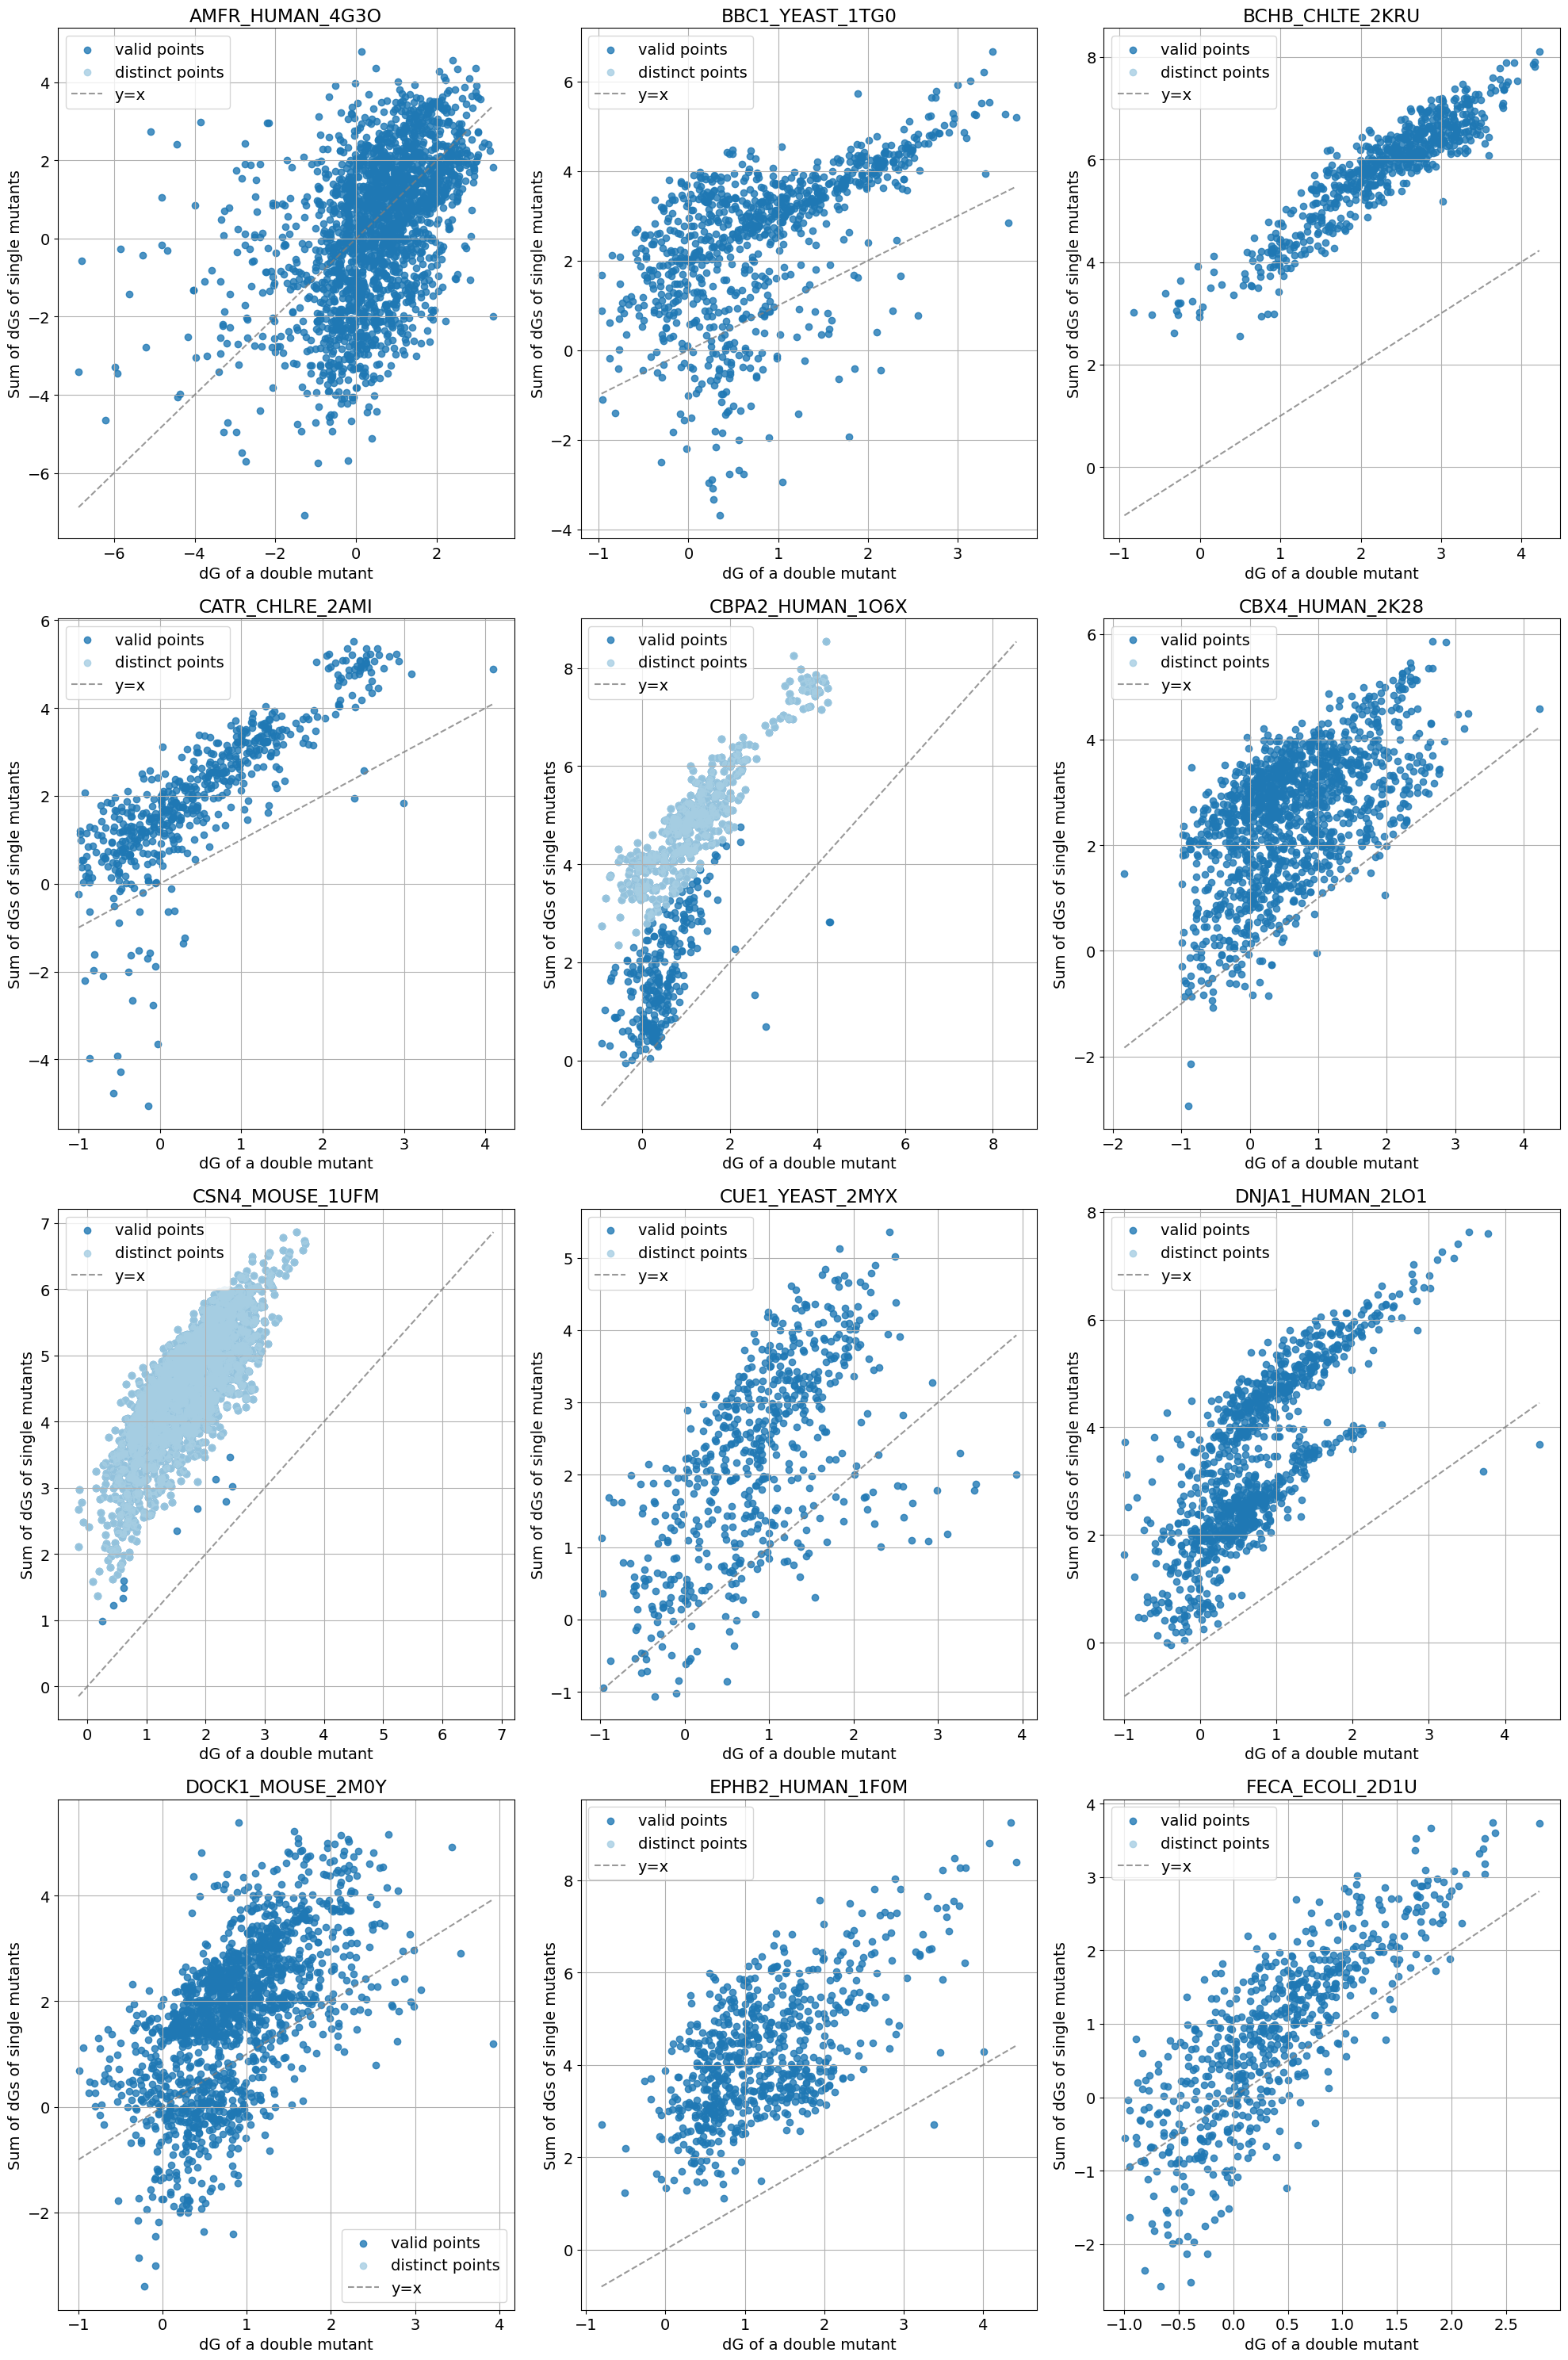

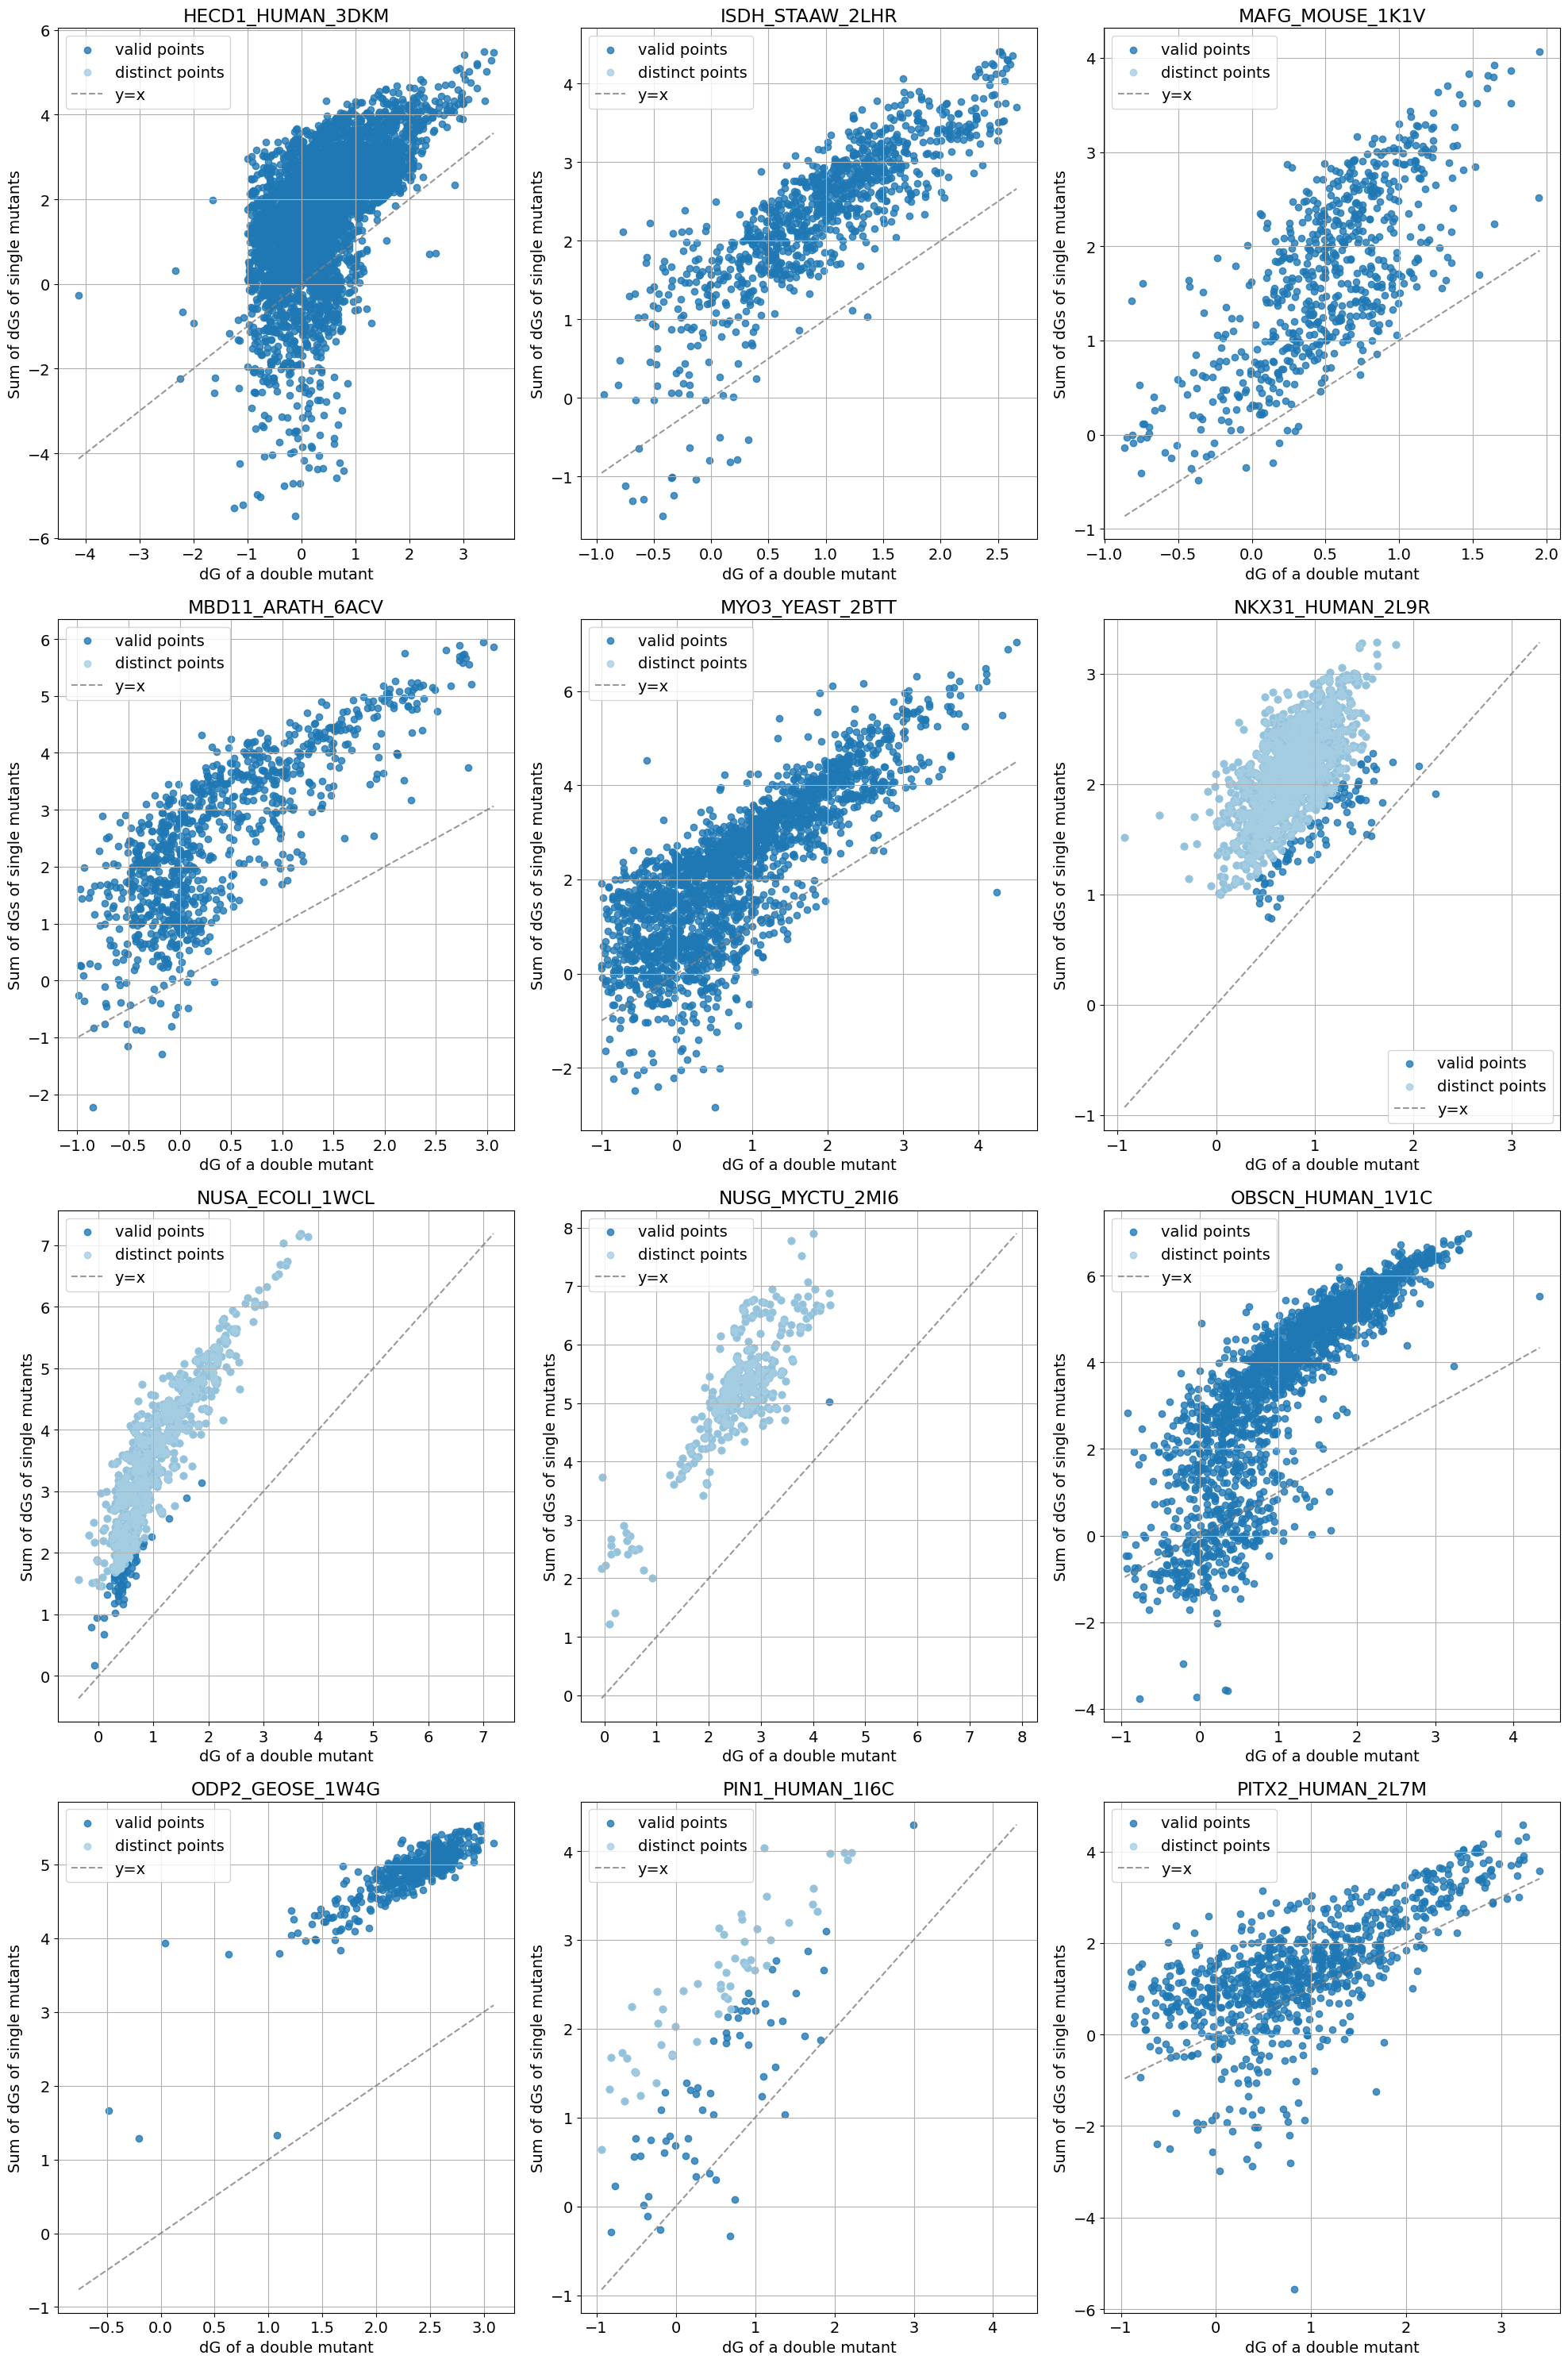

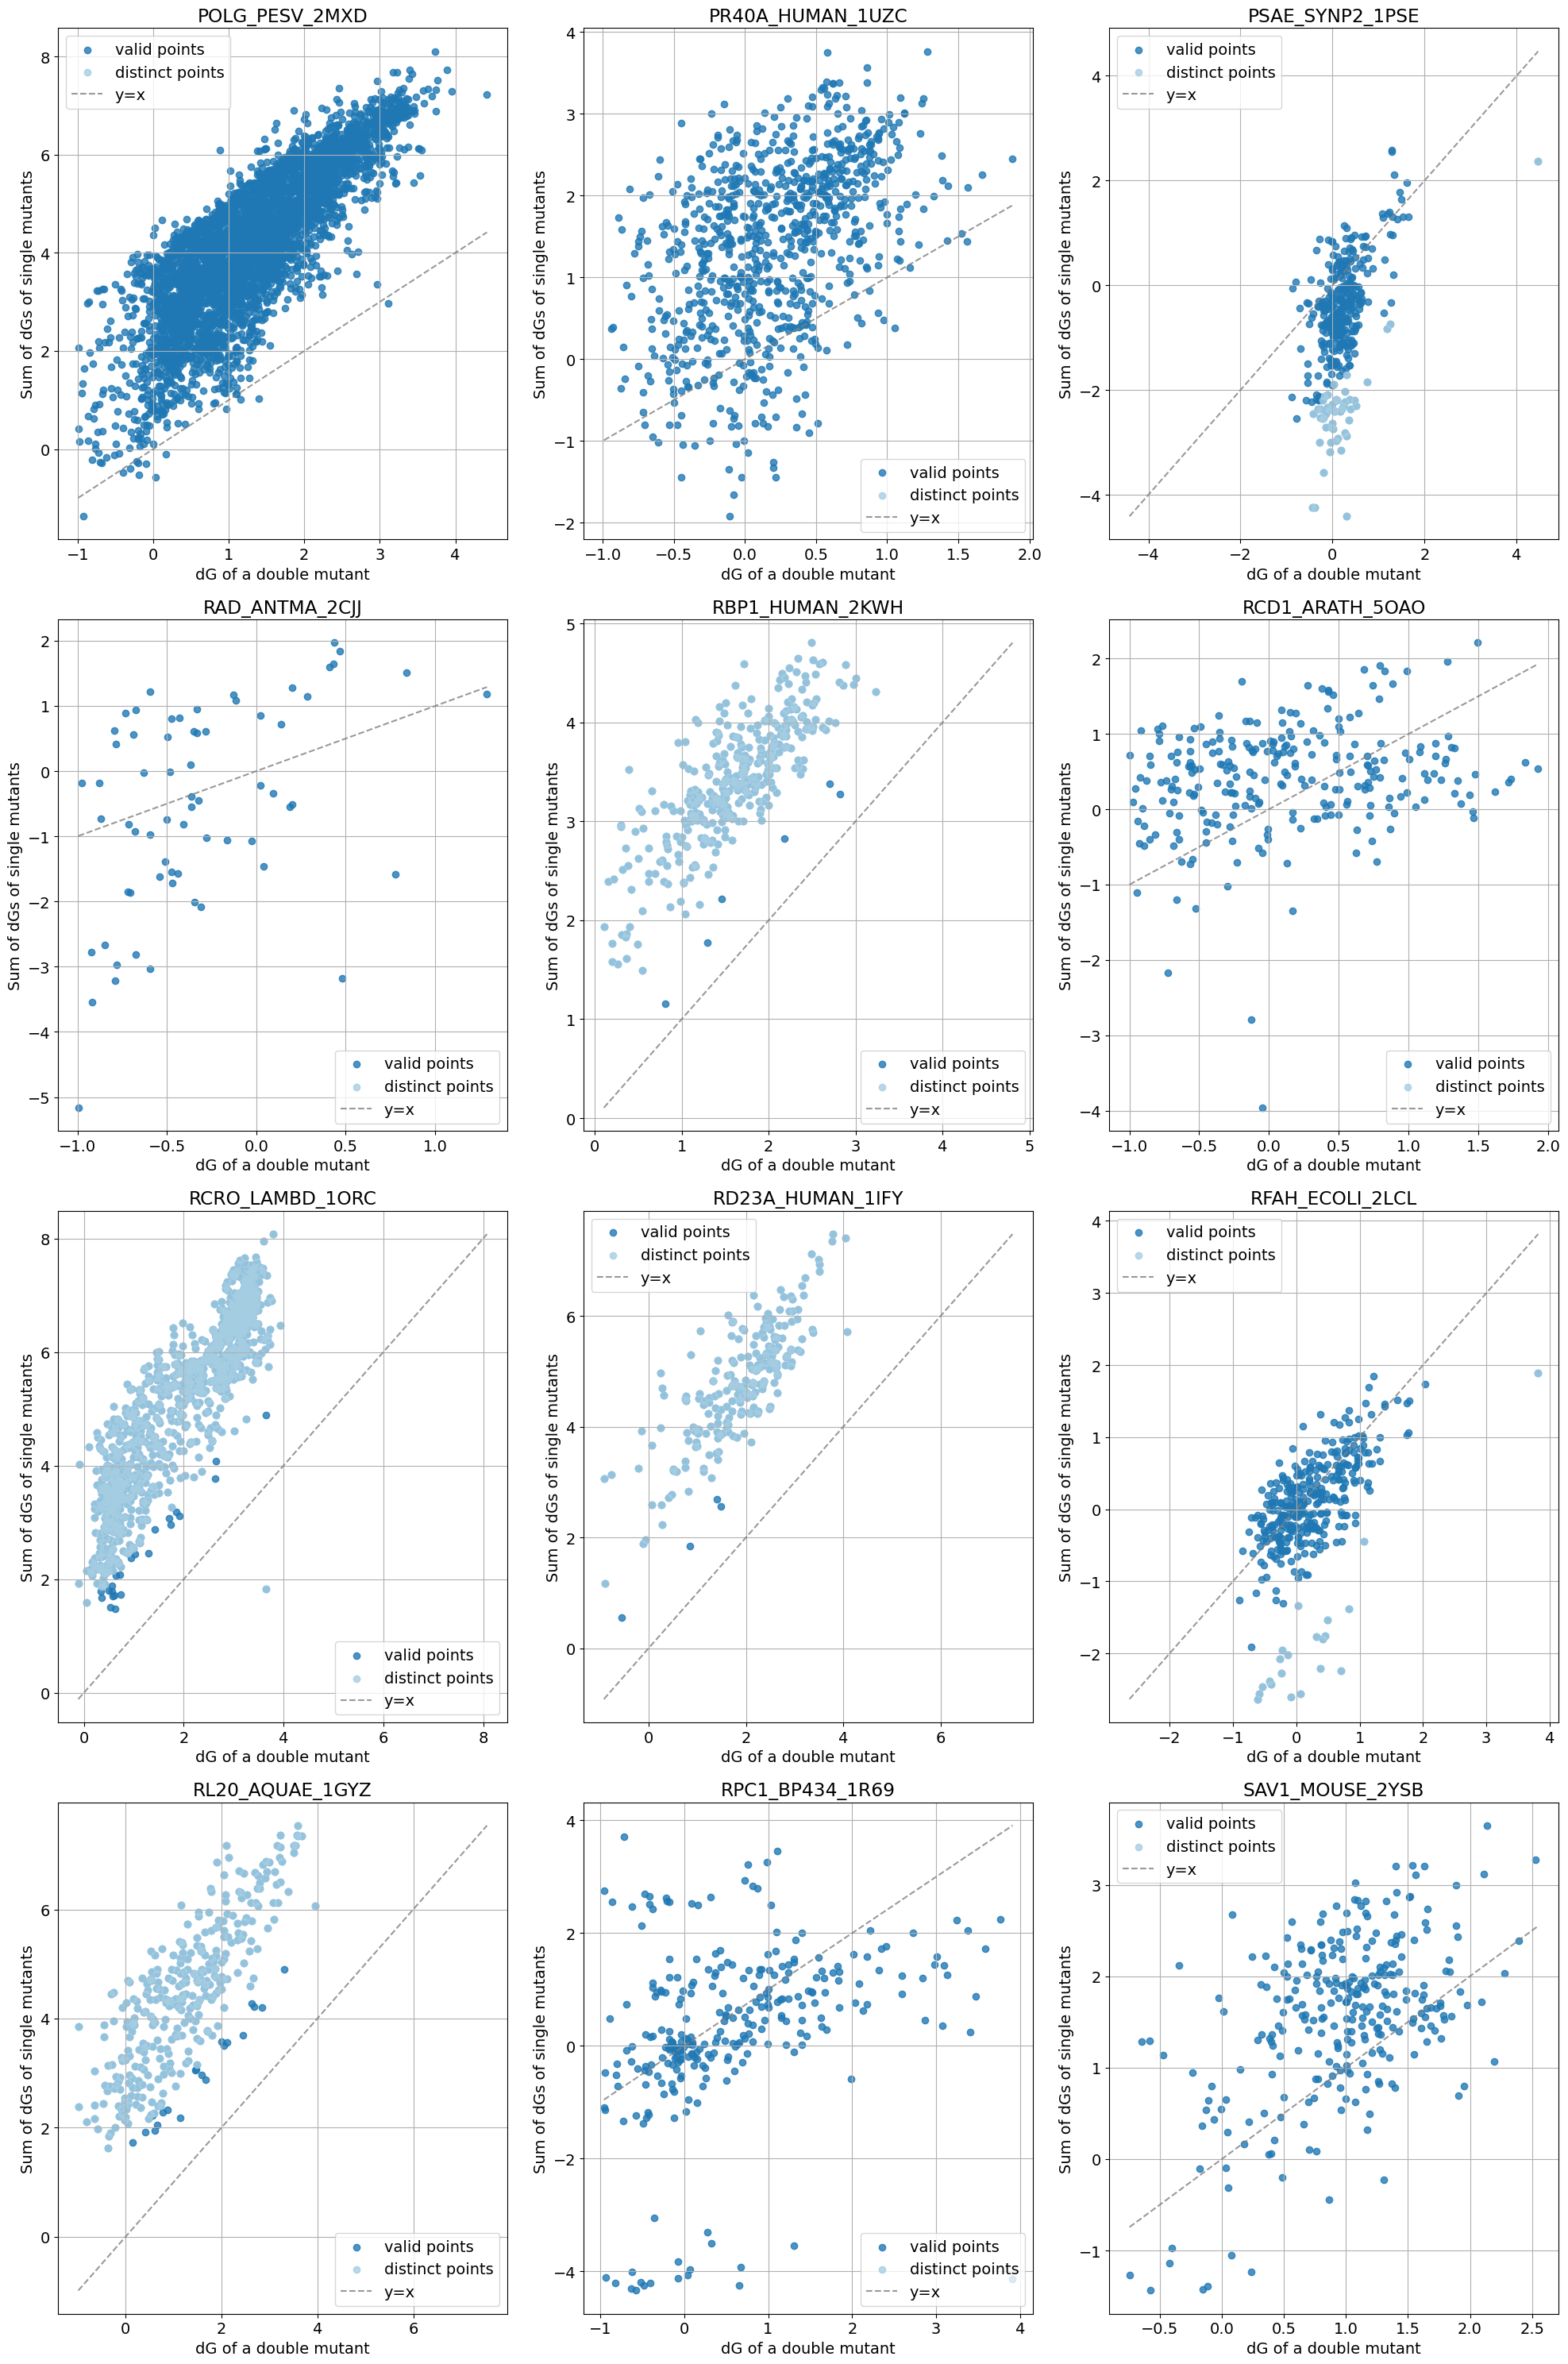

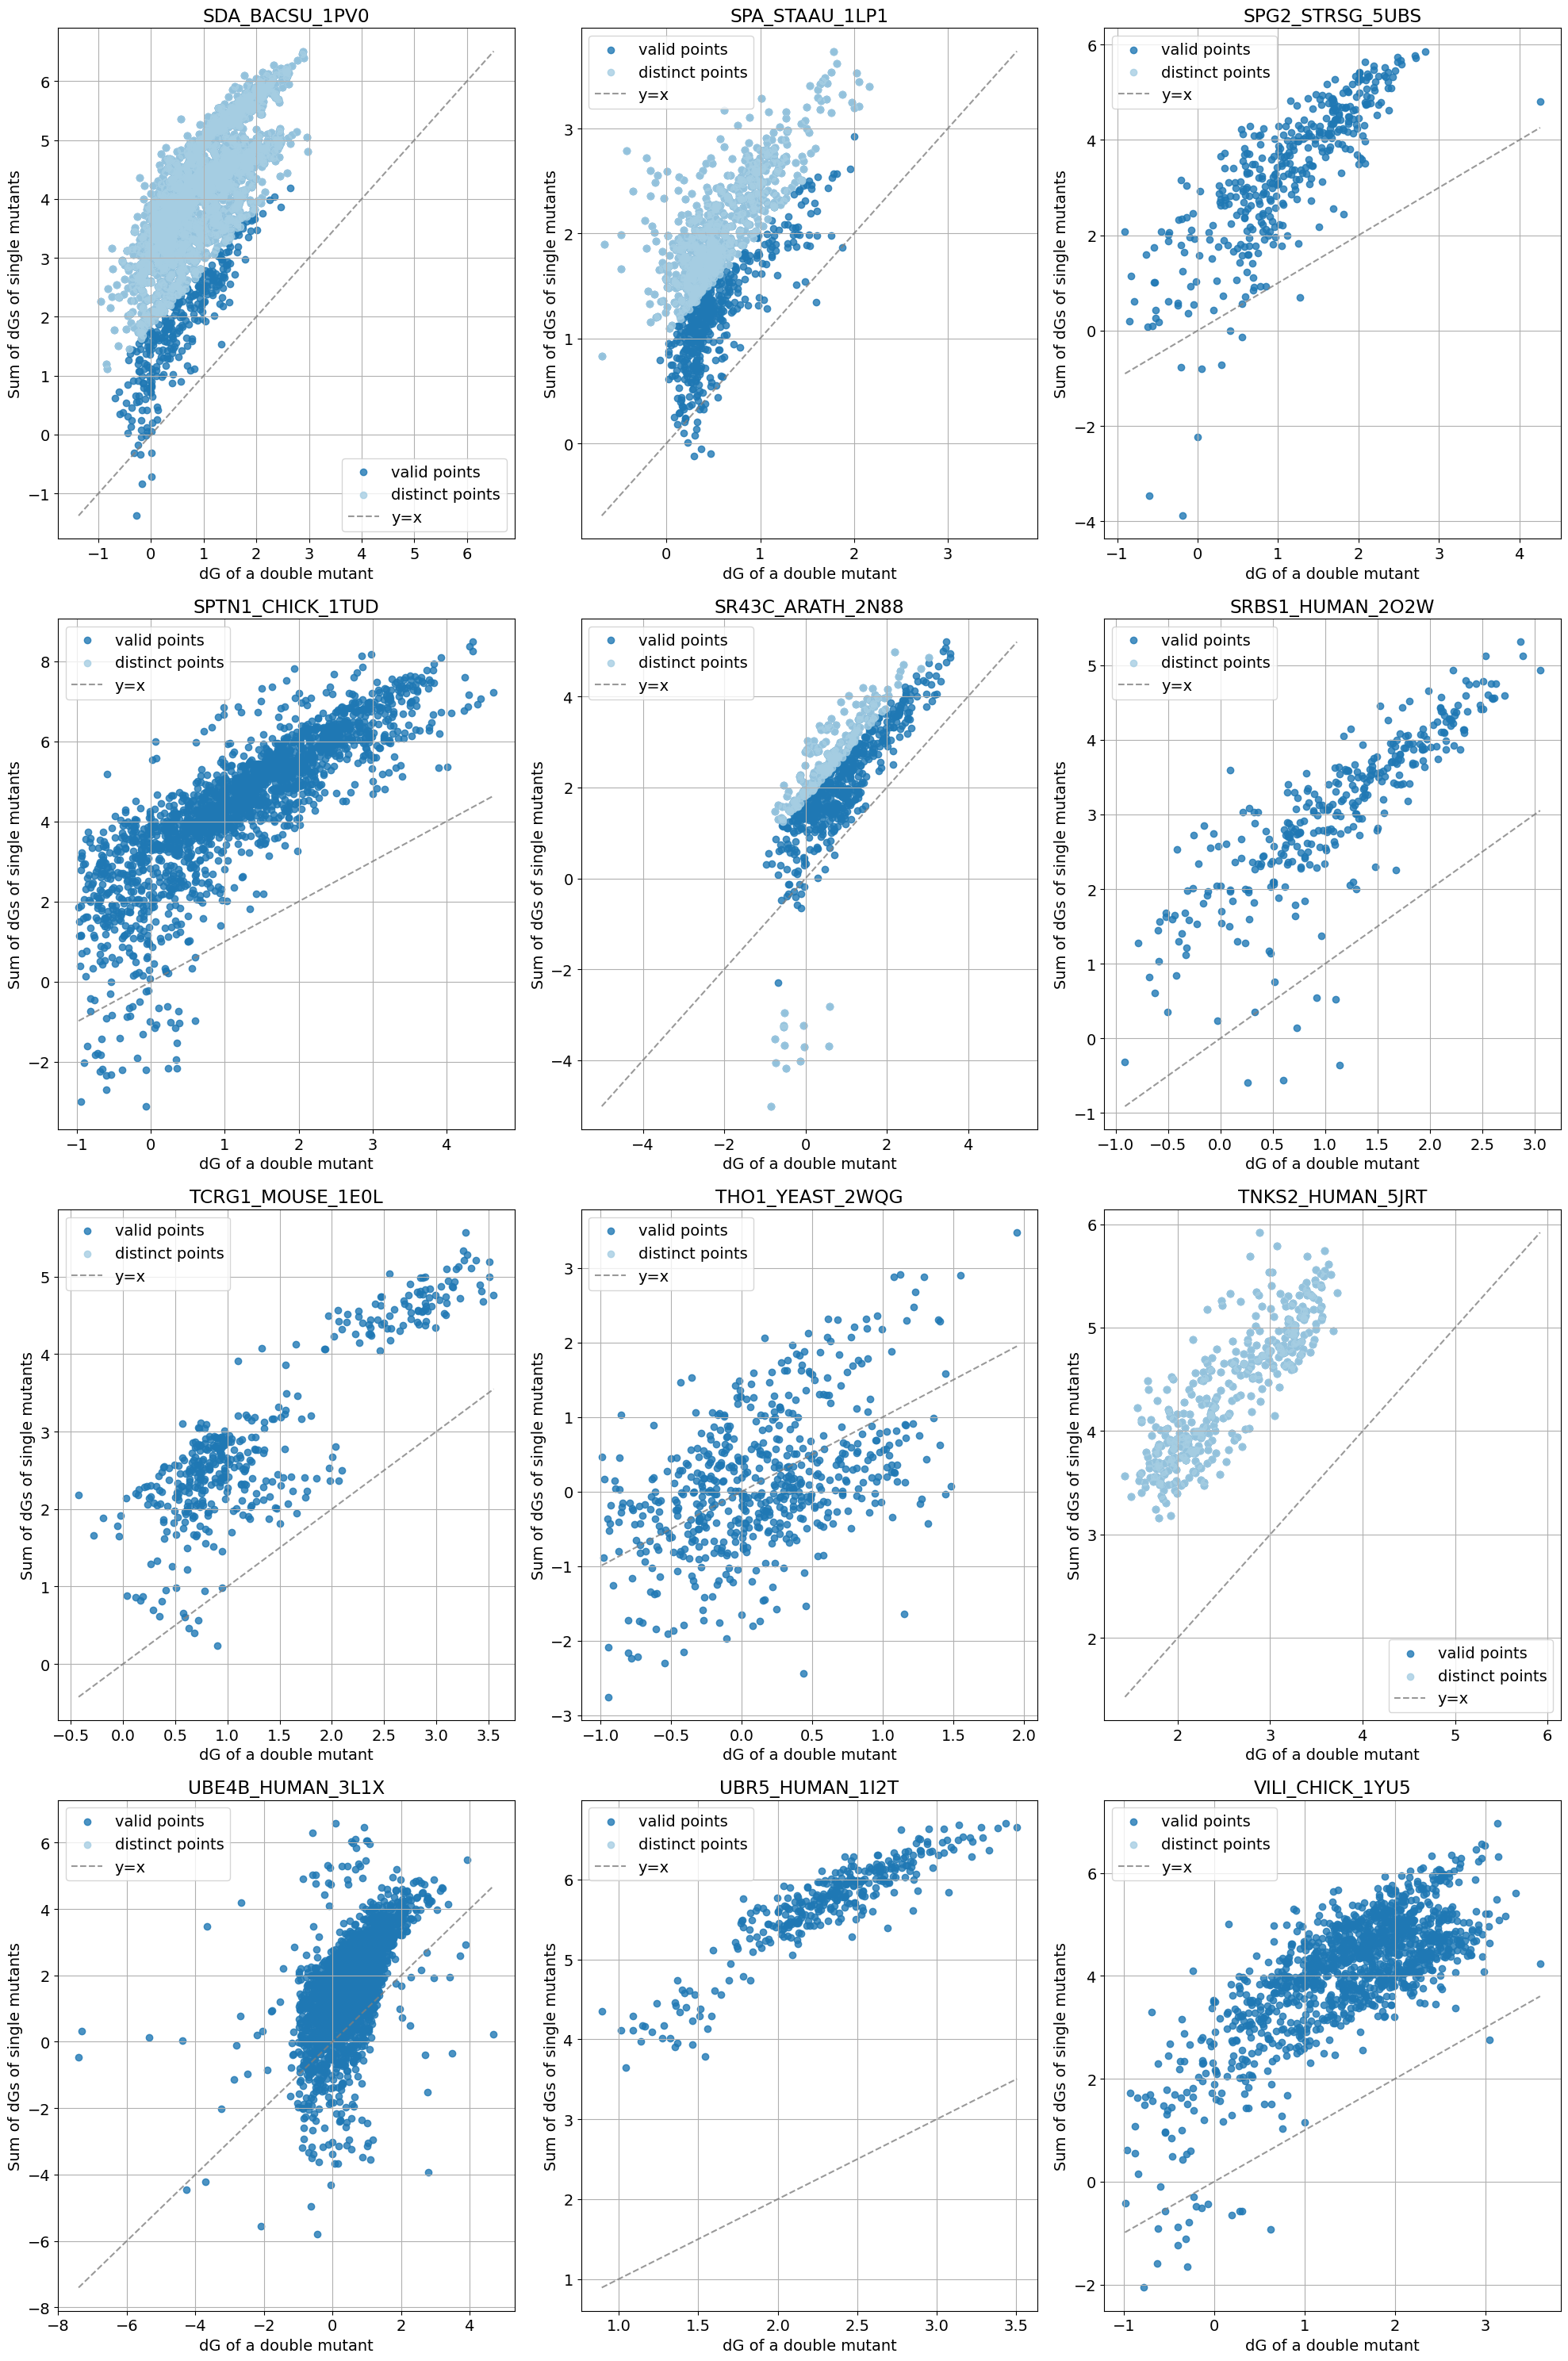

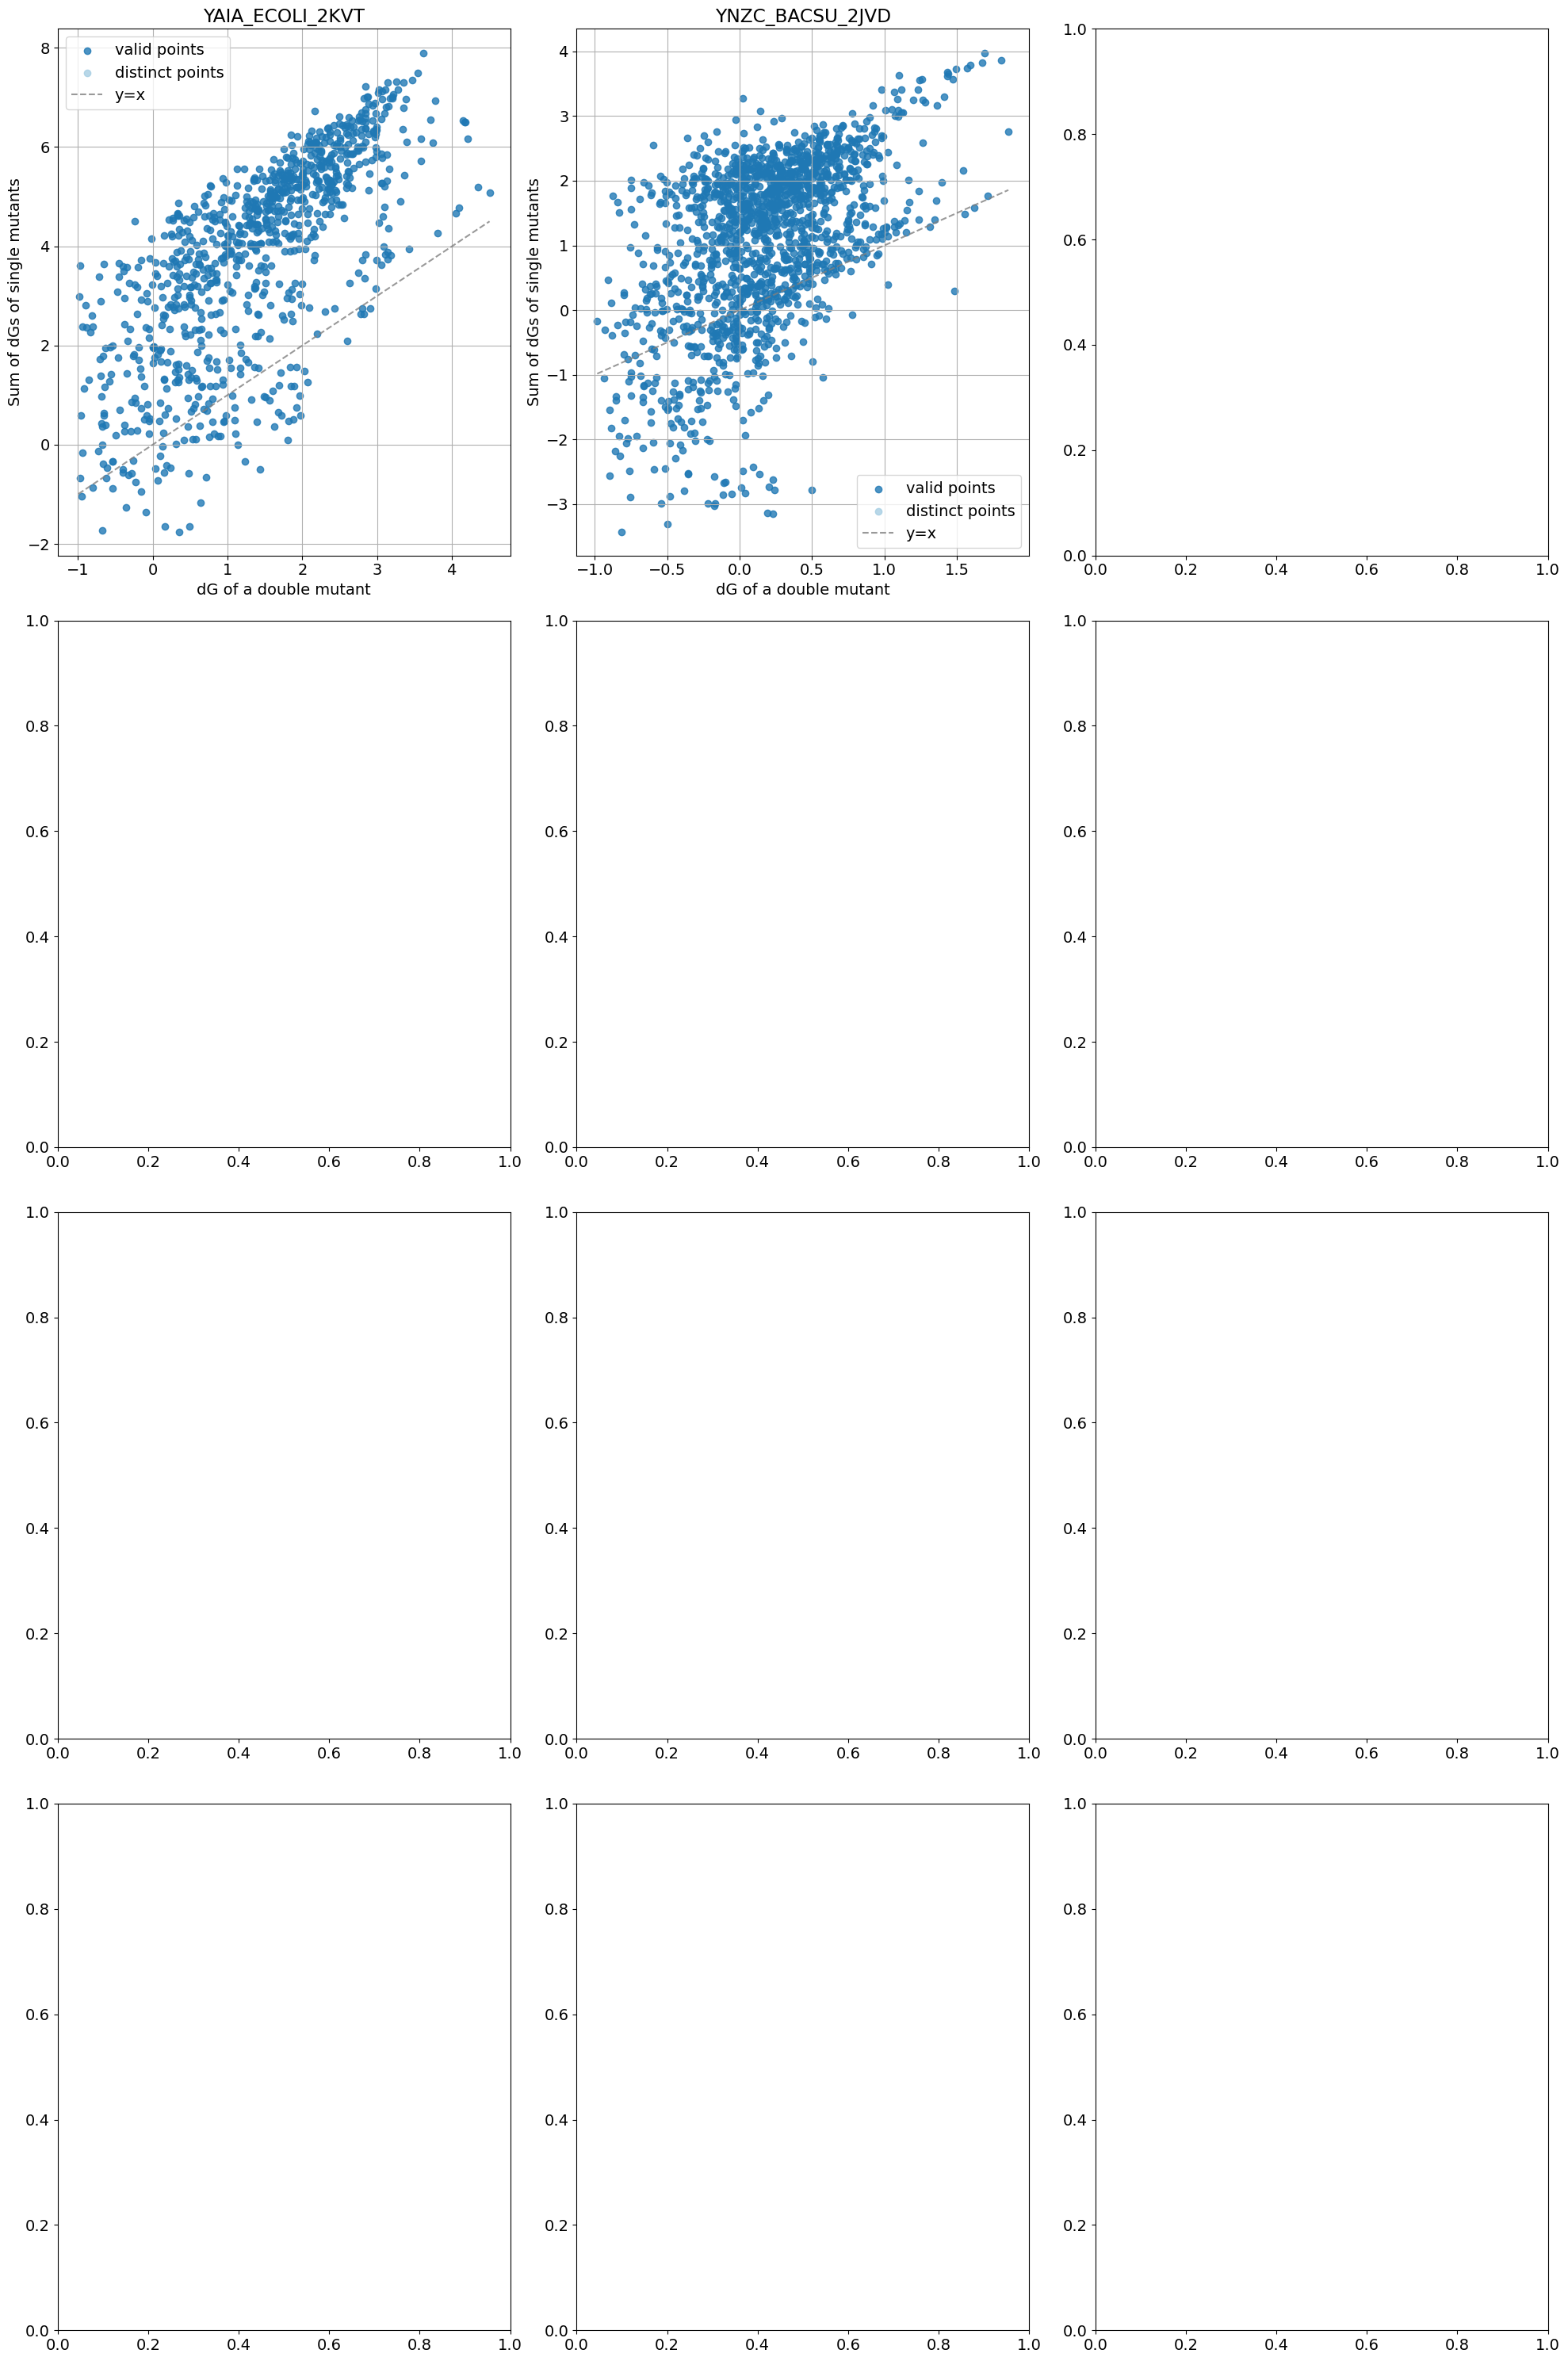

In [5]:
plt.rcParams.update({'font.size': 14})
subsets = []
start = 0
while start != 48:
    subsets.append(datasets[start:start+12])
    start += 12
subsets.append(datasets[start:])
for num in range(len(subsets)):
    subset = subsets[num]
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 30))
    for index in range(len(subset)):
        dataset = subset[index]
        name_elems = dataset.split('/')[-1].split('.')[0].split("_")
        name = name_elems[0] + "_" + name_elems[1] + "_" + name_elems[-1]
        df = pd.read_csv(dataset)
        x = df['dG'].values
        y = df['sum_dG'].values

        # Compute residuals = vertical distance from the diagonal (y = x)
        residuals = y - x
        # Compute standard deviation of residuals
        std_residual = np.std(residuals)
        # Define epistasis threshold: 2 standard deviations
        threshold = 2 * std_residual
        # Identify points with significant epistasis
        epistatic = np.abs(residuals) > threshold
        # Extract those x and y values
        distinct_x = x[epistatic]
        distinct_y = y[epistatic]

        x_vals = np.linspace(min(x.min(), y.min()), max(x.max(), y.max()), 100)
        
        i = index // 3
        j = index % 3
        cmap = plt.get_cmap('Paired')
        axes[i, j].scatter(x, y, color=cmap(1), alpha=0.8, label='valid points')
        axes[i, j].scatter(distinct_x, distinct_y, color=cmap(0), alpha=0.8, label='distinct points')
        axes[i, j].plot(x_vals, x_vals, color='grey', alpha=0.8, linestyle='--', label='y=x')
        axes[i, j].set_title(f'{name}')
        axes[i, j].set_xlabel('dG of a double mutant')
        axes[i, j].set_ylabel('Sum of dGs of single mutants')
        axes[i, j].legend()
        axes[i, j].grid(True)
    plt.tight_layout()
    plt.savefig(f'Tsuboyama/plots/sum_dg_part{num}.png')

In [6]:
import os

datasets = []
tsuboyama_folder = "Tsuboyama/to_plot_recon_dg"
for file in os.listdir(tsuboyama_folder):
    file_path = os.path.join(tsuboyama_folder, file)
    datasets.append(file_path)

In [ ]:
plt.rcParams.update({'font.size': 14})
subsets = []
start = 0
while start != 48:
    subsets.append(datasets[start:start+12])
    start += 12
subsets.append(datasets[start:])
for num in range(len(subsets)):
    subset = subsets[num]
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 30))
    for index in range(len(subset)):
        dataset = subset[index]
        name_elems = dataset.split('/')[-1].split('.')[0].split("_")
        name = name_elems[0] + "_" + name_elems[1] + "_" + name_elems[-1]
        df = pd.read_csv(dataset)
        x = df['dG'].values
        y = df['recon_dg'].values

        # Compute residuals = vertical distance from the diagonal (y = x)
        residuals = y - x
        # Compute standard deviation of residuals
        std_residual = np.std(residuals)
        # Define epistasis threshold: 2 standard deviations
        threshold = 2 * std_residual
        # Identify points with significant epistasis
        epistatic = np.abs(residuals) > threshold
        # Extract those x and y values
        distinct_x = x[epistatic]
        distinct_y = y[epistatic]

        x_vals = np.linspace(min(x.min(), y.min()), max(x.max(), y.max()), 100)
        
        i = index // 3
        j = index % 3
        cmap = plt.get_cmap('Paired')
        axes[i, j].scatter(x, y, color=cmap(1), alpha=0.8, label='valid points')
        axes[i, j].scatter(distinct_x, distinct_y, color=cmap(0), alpha=0.8, label='distinct points')
        axes[i, j].plot(x_vals, x_vals, color='grey', alpha=0.8, linestyle='--', label='y=x')
        axes[i, j].set_title(f'{name}')
        axes[i, j].set_xlabel('dG of a double mutant')
        axes[i, j].set_ylabel('Sum of dGs of single mutants')
        axes[i, j].legend()
        axes[i, j].grid(True)
    plt.tight_layout()
    plt.savefig(f'Tsuboyama/plots/recon_dg_part{num}.png')